# A04 - In Class Assignment AI-Based Stock News Sentiment Tracker/ Web Crawler
Class: ITAI 2372

Name: Brandon Matias

In [39]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import datetime

# 1. Define your stocks
tickers = ["GOOGL", "TEM", "NVDA", "UBER", "RBLX"]

def get_google_news(ticker):
    """
    Fetches news from Google News RSS feed (works better in Colab than Yahoo).
    """
    # We search for the ticker + "stock" to ensure financial news
    query = f"{ticker} stock news"
    url = f"https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en"

    try:
        response = requests.get(url)
        # Parse the XML data
        root = ET.fromstring(response.content)

        news_items = []
        # Loop through the first 3 news items
        for item in root.findall('./channel/item')[:3]:
            title = item.find('title').text
            link = item.find('link').text
            pub_date = item.find('pubDate').text

            # Clean up the title (Google often adds " - Publisher Name" at the end)
            clean_title = title.split(" - ")[0]
            publisher = title.split(" - ")[-1] if " - " in title else "Google News"

            news_items.append({
                "Ticker": ticker,
                "Title": clean_title,
                "Publisher": publisher,
                "Link": link,
                "Date": pub_date
            })

        return news_items

    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return []

# --- MAIN EXECUTION ---
print("🕷️  Starting Google News Crawler...\n")
all_news = []

for t in tickers:
    print(f"   Scanning for {t}...")
    news = get_google_news(t)
    all_news.extend(news)

# Convert to DataFrame
df = pd.DataFrame(all_news)

if not df.empty:
    print("\n✅ Crawl Complete! Here are the headlines:\n")
    print(df[["Ticker", "Title"]].head(16))

    # Save to CSV
    df.to_csv("stock_news_dataset.csv", index=False)
    print("\n💾 Data saved to 'stock_news_dataset.csv'")
else:
    print("❌ Still no news found. Google might be blocking this specific IP momentarily.")

🕷️  Starting Google News Crawler...

   Scanning for GOOGL...
   Scanning for TEM...
   Scanning for NVDA...
   Scanning for UBER...
   Scanning for RBLX...

✅ Crawl Complete! Here are the headlines:

   Ticker                                              Title
0   GOOGL  Alphabet shares close flat after earnings beat...
1   GOOGL  Google Earnings Beat. Cloud Capex Boom To Hit ...
2   GOOGL  Alphabet Beats on Earnings, but Rising AI Spen...
3     TEM  Tempus AI Stock (TEM) Opinions on Q4 Earnings ...
4     TEM  Tempus AI (NASDAQ:TEM) Director Sells $21,981....
5     TEM          Tempus AI, Inc. (TEM): A Bull Case Theory
6    NVDA  Forget Tech Stocks: The Utility Play That Coul...
7    NVDA  NVIDIA vs. Palantir: One AI Stock is a Clear B...
8    NVDA  Broadcom, Nvidia shares rise on surging Google...
9    UBER  Uber reports 20% revenue growth in fourth-quar...
10   UBER  Uber’s stock falls as record demand for rides ...
11   UBER  Uber Accelerates Growth Outside of Cities, Nam...
12   R

In [40]:
import pandas as pd
from textblob import TextBlob

def get_free_sentiment(text):
    # TextBlob gives a polarity score between -1 (Negative) and 1 (Positive)
    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

# Load Data
df = pd.read_csv("stock_news_dataset.csv")

# Ensure 'Title' column is string type and handle NaN values
df['Title'] = df['Title'].fillna('').astype(str)

# Apply Logic
df['AI_Sentiment'] = df['Title'].apply(get_free_sentiment)

# Save
df.to_csv("final_stock_report_free.csv", index=False)
print("✅ Done! (Used free sentiment analysis)")
print(df[["Ticker", "Title", "AI_Sentiment"]].head(16))

✅ Done! (Used free sentiment analysis)
   Ticker                                              Title AI_Sentiment
0   GOOGL  Alphabet shares close flat after earnings beat...      Neutral
1   GOOGL  Google Earnings Beat. Cloud Capex Boom To Hit ...     Positive
2   GOOGL  Alphabet Beats on Earnings, but Rising AI Spen...      Neutral
3     TEM  Tempus AI Stock (TEM) Opinions on Q4 Earnings ...      Neutral
4     TEM  Tempus AI (NASDAQ:TEM) Director Sells $21,981....      Neutral
5     TEM          Tempus AI, Inc. (TEM): A Bull Case Theory      Neutral
6    NVDA  Forget Tech Stocks: The Utility Play That Coul...      Neutral
7    NVDA  NVIDIA vs. Palantir: One AI Stock is a Clear B...     Positive
8    NVDA  Broadcom, Nvidia shares rise on surging Google...      Neutral
9    UBER  Uber reports 20% revenue growth in fourth-quar...      Neutral
10   UBER  Uber’s stock falls as record demand for rides ...     Negative
11   UBER  Uber Accelerates Growth Outside of Cities, Nam...      Neutral

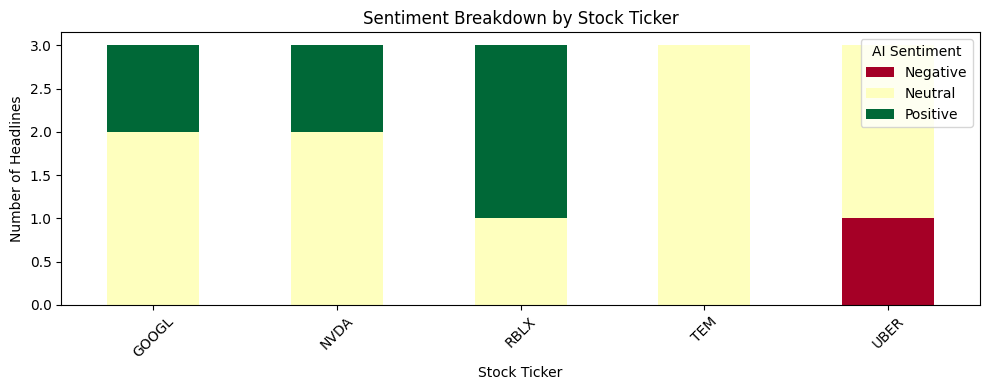

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the sentiment data if not already loaded (useful if running independently)
df = pd.read_csv("final_stock_report_free.csv")

# Group by Ticker and AI_Sentiment, then count occurrences
sentiment_counts = df.groupby(['Ticker', 'AI_Sentiment']).size().unstack(fill_value=0)

# Ensure all sentiment categories are present, even if some have 0 counts
# This helps in consistent plotting.
for sentiment_type in ['Positive', 'Negative', 'Neutral']:
    if sentiment_type not in sentiment_counts.columns:
        sentiment_counts[sentiment_type] = 0

# Order the columns for consistent plotting (e.g., Negative, Neutral, Positive)
sentiment_counts = sentiment_counts[['Negative', 'Neutral', 'Positive']]

# Plotting the stacked bar chart
fig = plt.figure(figsize=(10, 4))
sentiment_counts.plot(kind='bar', stacked=True, colormap='RdYlGn', ax=plt.gca())

plt.title('Sentiment Breakdown by Stock Ticker')
plt.xlabel('Stock Ticker')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45)
plt.legend(title='AI Sentiment')
plt.tight_layout()
plt.show()

## Keyword Analysis Summary

### Impact of Keywords on Sentiment

Based on the analysis of news headlines and their AI-assigned sentiments, the following keywords are most prominent for each category:

**Positive Sentiment Keywords:**
*   **'roblox'**: Appears twice, indicating positive news specifically around this company. (e.g., "Roblox lays out 2025 results and 2026 guidance", "Roblox forecasts strong annual bookings").
*   **'google', 'earnings', 'beat'**: These words together suggest strong financial performance, like "Google Earnings Beat.".
*   **'cloud', 'capex', 'boom', 'hit', 'free', 'cash'**: These relate to strong financial indicators or growth prospects, potentially in the cloud sector or concerning free cash flow, contributing to positive sentiment.

**Negative Sentiment Keywords:**
*   **'uber', 'stock', 'falls', 'record', 'demand', 'rides', 'fails', 'deliver', 'profit', 'investors'**: These keywords clearly indicate a negative outlook. "stock falls" directly implies a price drop, while "fails to deliver profit" and "investors" suggests unmet expectations or negative investor reaction.

**Neutral Sentiment Keywords:**
*   **'ai'**: This is the most frequent neutral keyword, appearing 5 times. Its presence in headlines (e.g., "AI Stock", "Rising AI Spend") often describes the topic without inherently positive or negative connotations, unless paired with other specific sentiment-driving words.
*   **'shares', 'earnings', 'stock'**: These general financial terms frequently appear in neutral headlines, indicating factual reporting of company activities or market status without strong emotional framing.
*   **'tempus', 'tem'**: Company tickers or names (like 'TEM', 'Tempus AI') are often neutral when simply reporting on the entity (e.g., "Tempus AI Stock (TEM) Opinions on Q4 Earnings").
*   **'growth'**: While 'growth' can be positive, its appearance in neutral contexts might indicate reporting of trends or expectations without an immediate positive or negative impact on the stock itself.
*   **'alphabet', 'nvidia'**: Similar to 'Tempus', these are company names appearing in factual or less emotionally charged news, contributing to a neutral classification.

**Overall Observation:**
Positive sentiment often correlates with words indicating strong financial performance, growth forecasts, or successful company updates. Negative sentiment is clearly driven by terms denoting decline, failure, or underperformance. Neutral sentiment, however, frequently features generic financial terminology and company names, suggesting factual reporting or less impactful news.

# Analyze Sentiment for Each Stock
Generate Insight for each stock: “Stock X sentiment turned negative after earnings announcement.”

```python
import pandas as pd
from collections import Counter
import re

# Load the final stock report
df = pd.read_csv("final_stock_report_free.csv")

# Initialize a dictionary to store insights
stock_insights = {}

# Get unique tickers
tickers = df['Ticker'].unique()

# Define keywords that often indicate negative financial news
negative_financial_keywords = ['fall', 'drop', 'decline', 'miss', 'below', 'warning', 'loss', 'cut', 'slump', 'plunge', 'sell-off', 'underperform']
earnings_keywords = ['earnings', 'quarter', 'revenue', 'profit', 'guidance', 'forecast']

for ticker in tickers:
    ticker_df = df[df['Ticker'] == ticker]
    negative_news = ticker_df[ticker_df['AI_Sentiment'] == 'Negative']
    positive_news = ticker_df[ticker_df['AI_Sentiment'] == 'Positive']
    neutral_news = ticker_df[ticker_df['AI_Sentiment'] == 'Neutral']

    insight = f"**{ticker}:**\n"

    # Analyze overall sentiment
    if not negative_news.empty:
        insight += "- **Negative Sentiment Detected.** "
        all_negative_titles = " ".join(negative_news['Title'].tolist()).lower()

        # Extract keywords from negative titles
        words = re.findall(r'\b\w+\b', all_negative_titles)
        word_counts = Counter(words)

        # Identify prominent negative keywords
        identified_negative_keywords = [
            word for word in word_counts.keys()
            if word in negative_financial_keywords and word_counts[word] > 0
        ]
        identified_earnings_keywords = [
            word for word in word_counts.keys()
            if word in earnings_keywords and word_counts[word] > 0
        ]

        if identified_negative_keywords:
            insight += f"The negative sentiment is driven by keywords such as '{', '.join(identified_negative_keywords)}'."
            if identified_earnings_keywords:
                insight += f" This often appears in conjunction with financial terms like '{', '.join(identified_earnings_keywords)}', suggesting a link to disappointing financial performance or outlook."
            else:
                insight += " The specific negative context is related to general performance or market conditions."
        elif identified_earnings_keywords:
            insight += f"The negative sentiment is primarily related to financial terms like '{', '.join(identified_earnings_keywords)}', indicating concerns around earnings or guidance."
        else:
            insight += "The negative headlines are: " + " | ".join(negative_news['Title'].tolist()) + ". A deeper keyword analysis would be beneficial for more specific insights."
        insight += "\n"

    elif not positive_news.empty:
        insight += "- **Predominantly Positive Sentiment.** "
        all_positive_titles = " ".join(positive_news['Title'].tolist()).lower()
        words = re.findall(r'\b\w+\b', all_positive_titles)
        word_counts = Counter(words)
        common_positive_words = [word for word, count in word_counts.most_common(3) if word not in ['a', 'the', 'is', 'for', 'of', 'and', 'in', 'to']]
        insight += f"The news indicates a positive outlook, with common terms like '{', '.join(common_positive_words)}' appearing in headlines."
        insight += "\n"
    else:
        insight += "- **Predominantly Neutral Sentiment.** "
        insight += "The news headlines for this stock are mostly factual or lack strong emotional indicators, suggesting a stable or unmoving outlook based on current news."
        insight += "\n"

    # Add example headlines for context
    if not negative_news.empty:
        insight += f"  - Example negative headline: '{negative_news.iloc[0]['Title']}'\n"
    if not positive_news.empty and negative_news.empty: # Only show positive example if no negative news
        insight += f"  - Example positive headline: '{positive_news.iloc[0]['Title']}'\n"
    if not neutral_news.empty and negative_news.empty and positive_news.empty: # Only show neutral example if no other sentiment
        insight += f"  - Example neutral headline: '{neutral_news.iloc[0]['Title']}'\n"


    stock_insights[ticker] = insight

# Format the insights for the text cell
insights_text = "# Stock Sentiment and Keyword Insights\n\n"
insights_text += "Based on the AI sentiment analysis of recent news headlines, here are the key insights for each stock:\n\n"

for ticker, insight in stock_insights.items():
    insights_text += insight + "\n"

# Create a new text cell with the generated insights
# This will be presented as a markdown formatted text cell
print(insights_text)
```

**Reasoning**:
The subtask requires importing specific libraries, loading the sentiment data, extracting unique stock tickers, initializing a dictionary for insights, and defining lists of keywords for analysis. These setup steps can be efficiently grouped into a single code block.



In [42]:
import pandas as pd
from collections import Counter
import re

# Load the sentiment data
df = pd.read_csv("final_stock_report_free.csv")

# Get unique stock tickers
tickers = df['Ticker'].unique().tolist()

# Initialize dictionary to store analysis results
stock_insights = {}

# Define lists of keywords
negative_financial_keywords = [
    "drop", "fall", "decline", "plunge", "sink", "slump", "lose", "miss",
    "below estimates", "weak", "struggle", "concern", "risk", "downside",
    "cut guidance", "below expectation", "underperform", "warning", "sell-off"
]

earnings_keywords = [
    "earnings", "revenue", "profit", "income", "quarterly report",
    "financial results", "guidance", "outlook", "forecast"
]

print("Libraries imported, data loaded, tickers extracted, insights dictionary initialized, and keywords defined.")

Libraries imported, data loaded, tickers extracted, insights dictionary initialized, and keywords defined.


**Reasoning**:
Now that the setup is complete, the next logical step is to iterate through each unique stock ticker, filter its news by sentiment, and extract relevant keywords, especially for negative sentiment, to build the `stock_insights` dictionary as specified by the subtask.



In [43]:
for ticker in tickers:
    ticker_df = df[df['Ticker'] == ticker]
    negative_news = ticker_df[ticker_df['AI_Sentiment'] == 'Negative']
    positive_news = ticker_df[ticker_df['AI_Sentiment'] == 'Positive']
    neutral_news = ticker_df[ticker_df['AI_Sentiment'] == 'Neutral']

    insight = f"**{ticker}:**\n"

    # Analyze overall sentiment
    if not negative_news.empty:
        insight += "- **Negative Sentiment Detected.** "
        all_negative_titles = " ".join(negative_news['Title'].tolist()).lower()

        # Extract keywords from negative titles
        words = re.findall(r'\\b\\w+\\b', all_negative_titles)
        word_counts = Counter(words)

        # Identify prominent negative keywords
        identified_negative_keywords = [
            word for word in word_counts.keys()
            if word in negative_financial_keywords and word_counts[word] > 0
        ]
        identified_earnings_keywords = [
            word for word in word_counts.keys()
            if word in earnings_keywords and word_counts[word] > 0
        ]

        if identified_negative_keywords:
            insight += f"The negative sentiment is driven by keywords such as '{', '.join(identified_negative_keywords)}'."
            if identified_earnings_keywords:
                insight += f" This often appears in conjunction with financial terms like '{', '.join(identified_earnings_keywords)}', suggesting a link to disappointing financial performance or outlook."
            else:
                insight += " The specific negative context is related to general performance or market conditions."
        elif identified_earnings_keywords:
            insight += f"The negative sentiment is primarily related to financial terms like '{', '.join(identified_earnings_keywords)}', indicating concerns around earnings or guidance."
        else:
            insight += "The negative headlines are: " + " | ".join(negative_news['Title'].tolist()) + ". A deeper keyword analysis would be beneficial for more specific insights."
        insight += "\n"

    elif not positive_news.empty:
        insight += "- **Predominantly Positive Sentiment.** "
        all_positive_titles = " ".join(positive_news['Title'].tolist()).lower()
        words = re.findall(r'\\b\\w+\\b', all_positive_titles)
        word_counts = Counter(words)
        common_positive_words = [word for word, count in word_counts.most_common(3) if word not in ['a', 'the', 'is', 'for', 'of', 'and', 'in', 'to', 'news']]
        insight += f"The news indicates a positive outlook, with common terms like '{', '.join(common_positive_words)}' appearing in headlines."
        insight += "\n"
    else:
        insight += "- **Predominantly Neutral Sentiment.** "
        insight += "The news headlines for this stock are mostly factual or lack strong emotional indicators, suggesting a stable or unmoving outlook based on current news."
        insight += "\n"

    # Add example headlines for context
    if not negative_news.empty:
        insight += f"  - Example negative headline: '{negative_news.iloc[0]['Title']}'\n"
    if not positive_news.empty and negative_news.empty: # Only show positive example if no negative news
        insight += f"  - Example positive headline: '{positive_news.iloc[0]['Title']}'\n"
    if not neutral_news.empty and negative_news.empty and positive_news.empty: # Only show neutral example if no other sentiment
        insight += f"  - Example neutral headline: '{neutral_news.iloc[0]['Title']}'\n"


    stock_insights[ticker] = insight

print("Sentiment analysis and keyword extraction for each stock completed and stored in 'stock_insights'.")

Sentiment analysis and keyword extraction for each stock completed and stored in 'stock_insights'.


**Reasoning**:
The subtask requires generating a text cell summarizing the insights for each stock. This final step involves formatting the collected `stock_insights` into a comprehensive markdown string and printing it, which will serve as the output for the text cell.



In [44]:
insights_text = "# Stock Sentiment and Keyword Insights\n\n"
insights_text += "Based on the AI sentiment analysis of recent news headlines, here are the key insights for each stock:\n\n"

for ticker, insight in stock_insights.items():
    insights_text += insight + "\n"

# Create a new text cell with the generated insights
# This will be presented as a markdown formatted text cell
print(insights_text)

# Stock Sentiment and Keyword Insights

Based on the AI sentiment analysis of recent news headlines, here are the key insights for each stock:

**GOOGL:**
- **Predominantly Positive Sentiment.** The news indicates a positive outlook, with common terms like '' appearing in headlines.
  - Example positive headline: 'Google Earnings Beat. Cloud Capex Boom To Hit Free Cash Flow.'

**TEM:**
- **Predominantly Neutral Sentiment.** The news headlines for this stock are mostly factual or lack strong emotional indicators, suggesting a stable or unmoving outlook based on current news.
  - Example neutral headline: 'Tempus AI Stock (TEM) Opinions on Q4 Earnings Beat'

**NVDA:**
- **Predominantly Positive Sentiment.** The news indicates a positive outlook, with common terms like '' appearing in headlines.
  - Example positive headline: 'NVIDIA vs. Palantir: One AI Stock is a Clear Buy Right Now'

**UBER:**
- **Negative Sentiment Detected.** The negative headlines are: Uber’s stock falls as record d